# Insights on Condo Sales in Chicago
### 10 Questions for a Chicago Real-Estate Trivia Night — Condo Companion

The single-family piece's twin, run on Chicago **condominiums** (2022–2025). Same
questions, a different city: condos are a **downtown-and-North-lakefront** market, so
we add a fourth **Central** region (the Loop + Near North / South / West).

Condo unit characteristics (size, beds, baths) are **~70% unrecorded** in the county
data, so this companion is **price-based** — no $/sqft. Clean, arm's-length sample;
compute in `analysis/sales_descriptives.py`, renderers in `viz/charts.py`
(**entity = orange, individual = blue** wherever the two are split).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chicago_housing import constants as K
from chicago_housing.data.load import load_training_data
from chicago_housing.data import wrangling
from chicago_housing.analysis import sales_descriptives as sd
from chicago_housing.viz import charts, maps

pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

### Setup — the clean condo sample

Chicago + CONDO + 2022–25 → drop non-arm's-length. **No multi-card / prorated filter**:
condos have no multi-card concept and every unit is a *prorated* share of its building,
so those single-family filters don't apply. ~52,100 → **51,230** after validity; one
unmapped parcel dropped → **51,229**. The condo **four-region** map (Central added) is
attached last.

In [2]:
# One-call setup (wrangling.load_sales_sample): load -> scope -> rename -> classify
# + drop non-market -> attach region. Everything condo-specific (parquet, CONDO
# group, price-only, 4-region Central map) lives in the K.CONDO config; swap
# K.CONDO -> K.SF / K.MF for the other property types.
enriched = wrangling.load_sales_sample(K.CONDO)
print("clean condo sample:", enriched.shape)

scope_filter [condo]:  221,761 ->   52,103 rows


apply_drop_policy: 52,103 -> 51,230
  statutory (PTAX/family): 588
  below $10,000 floor:    0
  entity + price-corrob.:  375
dropped 1 unmapped / no-geo rows
add_region [condo]: {'Central': 17131, 'North': 25957, 'West': 4396, 'South': 3745}
clean condo sample: (51229, 28)


## First, the lay of the land — the condo city is downtown

Condos flip the single-family geography on its head. Where SF sales were a
South-and-North story, **condos are North (51%) and Central (33%)** — the lakefront
high-rises and the downtown core — with West and South a combined ~16%.

Because downtown *is* the condo market, we add a fourth region the SF piece didn't
need: **Central** — the Loop plus Near North, Near South, and Near West (River North,
Streeterville, South Loop, West Loop). In the SF piece those folded into N/W/S; here
they're the main event.

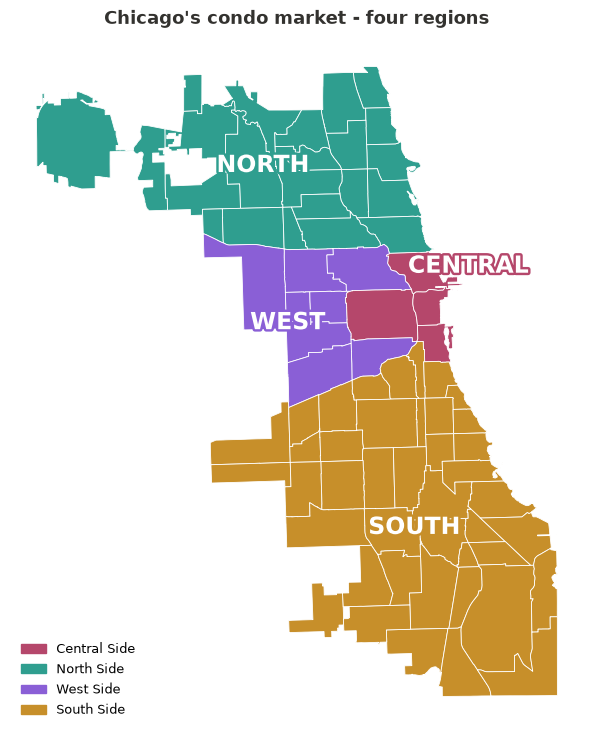

In [3]:
maps.region_map_static(K.CONDO, title="Chicago's condo market - four regions",
                       label_size=17, label_offsets={"Central": (14000, 9000), "West": (-6000, -3000)})
plt.show()

# interactive companion - hover any area for its side + condo sale count
maps.region_map(enriched, K.CONDO, sales_label="Condo sales 22-25:").save("condo_region_map.html")

---
## Q1 — How many condos sold in Chicago in 2025?

**About 9,900 — and unlike single-family, condos never stopped falling.** Sales slid
from 16,372 (2022) to 12,537 (2023, −23%), held flat in 2024, then dropped again to
9,921 in 2025 — **−39% over three years**, a steeper and more sustained decline than
the SF market, which fell once and then plateaued.

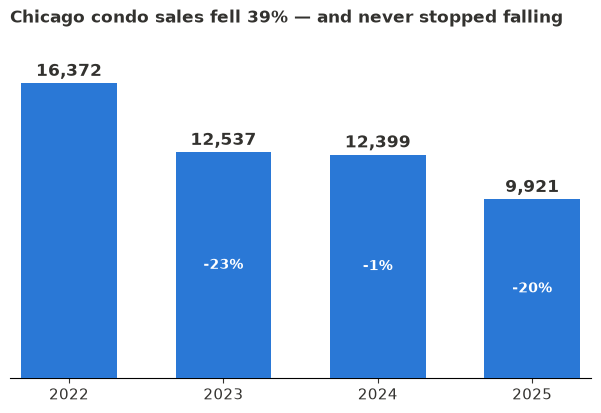

In [4]:
charts.plot_total_sales_by_year(
    sd.sales_by_year(enriched),
    title="Chicago condo sales fell 39% — and never stopped falling")
plt.show()

In [5]:
# Per-neighborhood condo volume 2022->2025 (busiest first).
nb_vol = sd.sales_by_neighborhood_wide(enriched)
_tot = nb_vol[['2022', '2023', '2024', '2025']].sum()
print(f"CITYWIDE  2022={_tot['2022']:,}  2023={_tot['2023']:,}  "
      f"2024={_tot['2024']:,}  2025={_tot['2025']:,}   ({len(nb_vol)} neighborhoods)")
nb_vol

CITYWIDE  2022=16,372  2023=12,537  2024=12,399  2025=9,921   (70 neighborhoods)


meta_year,loc_chicago_community_area_name,region,2022,2023,2024,2025,delta_pct
0,NEAR NORTH SIDE,Central,2586,2177,2315,1897,-26.600
1,LAKE VIEW,North,2154,1473,1391,1147,-46.800
2,LINCOLN PARK,North,1325,869,973,776,-41.400
3,WEST TOWN,West,1333,912,944,733,-45.000
4,NEAR WEST SIDE,Central,1086,744,810,592,-45.500
5,LOOP,Central,859,755,744,585,-31.900
6,UPTOWN,North,857,619,602,506,-41.000
7,EDGEWATER,North,825,797,609,477,-42.200
8,NEAR SOUTH SIDE,Central,632,503,467,379,-40.000
9,LOGAN SQUARE,North,532,362,401,305,-42.700


---
## Q2 — Where do condos actually sell?

**Almost entirely North and downtown.** The eight busiest condo neighborhoods in 2025
are *all* North or Central: **Near North Side (1,897)**, Lake View (1,147), Lincoln
Park (776), West Town (733), Near West Side (592), the Loop (585), Uptown (506),
Edgewater (477). By region: **North 51%, Central 33%**, West 9%, South 7% — the mirror
image of single-family, where the South Side led on volume.

In [6]:
# Condo sales by region, 2022->2025.
sd.sales_by_neighborhood_wide(enriched, group_by='region')

meta_year,region,2022,2023,2024,2025,delta_pct
0,North,8554,6434,6057,4912,-42.600
1,Central,5163,4179,4336,3453,-33.100
2,West,1482,1032,1060,822,-44.500
3,South,1173,892,946,734,-37.400


---
## Q3 — Did condo prices fall with volume?

**No — they rose more than houses did.** The citywide condo median climbed **+12.5%**
($311k → $350k, 2022→2025), even as sales fell 39%. Condo prices are also far more
*compressed* than single-family: the priciest condo neighborhood (Lincoln Park, $570k
median) is barely a third of the priciest SF neighborhood ($1.6M). The top of the
condo price table — **Lincoln Park ($570k), West Town ($569k), North Center ($540k),
Logan Square ($493k)** — is North/West, not the downtown high-rises.

Below: the full price table, then the busiest and priciest neighborhoods as
before/after bars.

In [7]:
# Full per-neighborhood median condo price, 2022 vs 2025 (+ counts + % change).
price = sd.median_price_two_year(enriched, '2022', '2025').join(
    enriched[[K.REPORT_GEO, K.REGION_COL]].drop_duplicates().set_index(K.REPORT_GEO))
_cw = enriched.groupby(enriched['meta_year'].astype('string'))[K.TARGET_RAW].median()
print(f"CITYWIDE median  2022 ${_cw['2022']:,.0f}  ->  2025 ${_cw['2025']:,.0f}"
      f"  ({(_cw['2025']/_cw['2022'] - 1) * 100:+.1f}%)")
price.sort_values('med_2025', ascending=False)

CITYWIDE median  2022 $311,234  ->  2025 $350,000  (+12.5%)


,med_2022,n_2022,med_2025,n_2025,delta_pct,region
loc_chicago_community_area_name,,,,,,
LINCOLN PARK,"470,000.000",1325,"570,000.000",776,21.300,North
WEST TOWN,"478,000.000",1333,"569,373.000",733,19.100,West
NORTH CENTER,"462,250.000",366,"540,000.000",213,16.800,North
LOGAN SQUARE,"408,782.000",532,"493,167.000",305,20.600,North
LAKE VIEW,"336,870.000",2154,"425,000.000",1147,26.200,North
NEAR NORTH SIDE,"365,651.500",2586,"390,000.000",1897,6.700,Central
LOWER WEST SIDE,"345,000.000",29,"389,500.000",32,12.900,West
FOREST GLEN,"326,118.000",8,"380,000.000",7,16.500,North
NEAR WEST SIDE,"342,661.500",1086,"367,145.000",592,7.100,Central


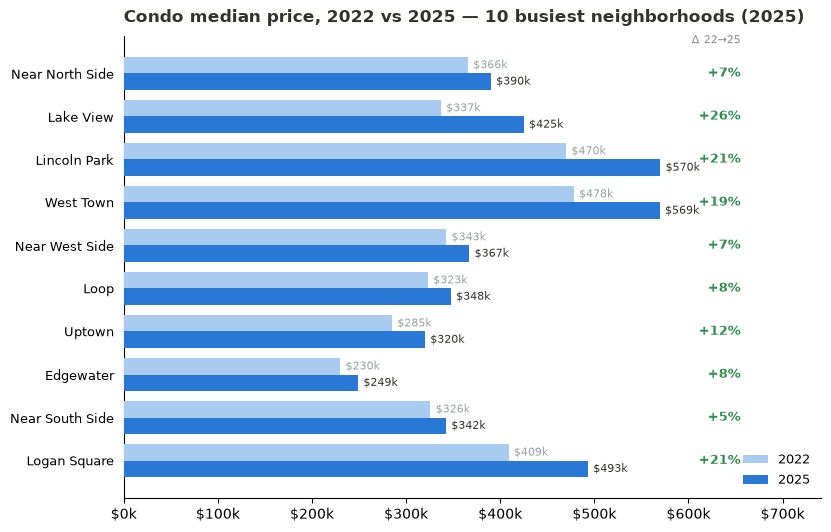

In [8]:
# 10 busiest condo neighborhoods (2025 volume): median price then vs now.
top10_vol = sd.top_neighborhoods(
    enriched[enriched['meta_year'].astype('string') == '2025'], 10)[K.REPORT_GEO].tolist()
charts.plot_median_price_2yr(
    price, top10_vol,
    "Condo median price, 2022 vs 2025 — 10 busiest neighborhoods (2025)")
plt.show()

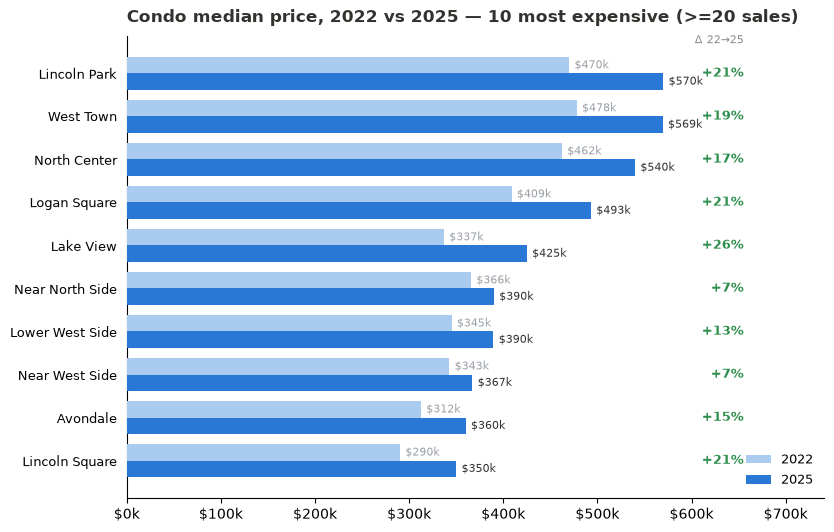

In [9]:
# 10 most expensive condo neighborhoods (2025 median, >=20 sales): then vs now.
top10_exp = sd.neighborhoods_by_year_price(
    enriched, year='2025', min_sales=20).head(10).index.tolist()
charts.plot_median_price_2yr(
    price, top10_exp,
    "Condo median price, 2022 vs 2025 — 10 most expensive (>=20 sales)")
plt.show()

---
## Q4 — What's the most expensive condo sold in Chicago?

**A $9.17M full-floor at 363 E Wacker** (the St. Regis) in the Loop, 2025 — followed by
**$8.5M at No. 9 Walton** in the Gold Coast. The entire condo trophy tier is **downtown
Central**: Loop and Near North high-rises.

*(Unit size / beds / baths aren't recorded for most condos, so the leaderboard is
price + year built + address + neighborhood — no $/sqft.)*

In [10]:
# Top 5 most expensive condo sales — 2022, then 2025 (price-only: no sqft/beds/baths).
from IPython.display import display
display(sd.top_sales(enriched, '2022', 5, include_size=False).style.hide(axis='index')
        .format({'price': '${:,.0f}'}).set_caption('Top 5 condos — 2022'))
display(sd.top_sales(enriched, '2025', 5, include_size=False).style.hide(axis='index')
        .format({'price': '${:,.0f}'}).set_caption('Top 5 condos — 2025'))

year,price,year_built,neighborhood,address,side
2022,"$10,225,000",2008,Near North Side,11 E WALTON ST 3700,Central
2022,"$9,400,000",2008,Near North Side,11 E WALTON ST 5500,Central
2022,"$8,960,000",2017,Near North Side,9 W WALTON ST 3002,Central
2022,"$6,900,000",2017,Near North Side,9 W WALTON ST 2802,Central
2022,"$5,330,000",2008,Near North Side,11 E WALTON ST 4002,Central


year,price,year_built,neighborhood,address,side
2025,"$9,174,519",2021,Loop,363 E WACKER DR 8401,Central
2025,"$8,500,000",2017,Near North Side,9 W WALTON ST 3600,Central
2025,"$7,483,200",2021,Loop,363 E WACKER DR 7901,Central
2025,"$7,400,000",2017,Near North Side,9 W WALTON ST 3500,Central
2025,"$6,525,000",1922,Near North Side,1300 N STATE PKY 1201,Central


In [11]:
# Combined leaderboard — both years' top 5, ranked by price.
combined = (pd.concat([sd.top_sales(enriched, '2022', 5, include_size=False),
                       sd.top_sales(enriched, '2025', 5, include_size=False)])
              .sort_values('price', ascending=False).reset_index(drop=True))
combined.style.hide(axis='index').format({'price': '${:,.0f}'}) \
    .set_caption('Most expensive condo sales, 2022 & 2025 combined')

year,price,year_built,neighborhood,address,side
2022,"$10,225,000",2008,Near North Side,11 E WALTON ST 3700,Central
2022,"$9,400,000",2008,Near North Side,11 E WALTON ST 5500,Central
2025,"$9,174,519",2021,Loop,363 E WACKER DR 8401,Central
2022,"$8,960,000",2017,Near North Side,9 W WALTON ST 3002,Central
2025,"$8,500,000",2017,Near North Side,9 W WALTON ST 3600,Central
2025,"$7,483,200",2021,Loop,363 E WACKER DR 7901,Central
2025,"$7,400,000",2017,Near North Side,9 W WALTON ST 3500,Central
2022,"$6,900,000",2017,Near North Side,9 W WALTON ST 2802,Central
2025,"$6,525,000",1922,Near North Side,1300 N STATE PKY 1201,Central
2022,"$5,330,000",2008,Near North Side,11 E WALTON ST 4002,Central


---
## Q5 — Do condo investors pay less?

**Same answer as single-family — it depends where — but downtown flips the sign.**
- **South & North:** entity buyers pay less (South −44%, North −19% in 2025).
- **Central (downtown):** entities pay a **+23% premium** — developers and bulk buyers
  paying *up* for downtown units, not bargain-hunting.

Price-only (no $/sqft for condos), so read this as an **association** — and unlike the
SF piece we can't rule out that investors simply buy smaller units.

,group,year,n_ent,n_ind,ent_share,price_ent,price_ind,price_diff_pct
0,Central,2022,467,4696,9.000,"345,000.000","345,000.000",0.000
1,North,2022,600,7954,7.000,"222,490.000","289,700.000",-23.000
2,West,2022,69,1413,5.000,"350,000.000","465,000.000",-25.000
3,South,2022,168,1005,14.000,"110,000.000","186,500.000",-41.000
4,Central,2025,396,3057,12.000,"450,000.000","365,000.000",23.000
5,North,2025,407,4505,8.000,"272,000.000","335,160.000",-19.000
6,West,2025,29,793,4.000,"504,000.000","542,802.000",-7.000
7,South,2025,118,616,16.000,"115,000.000","205,000.000",-44.000


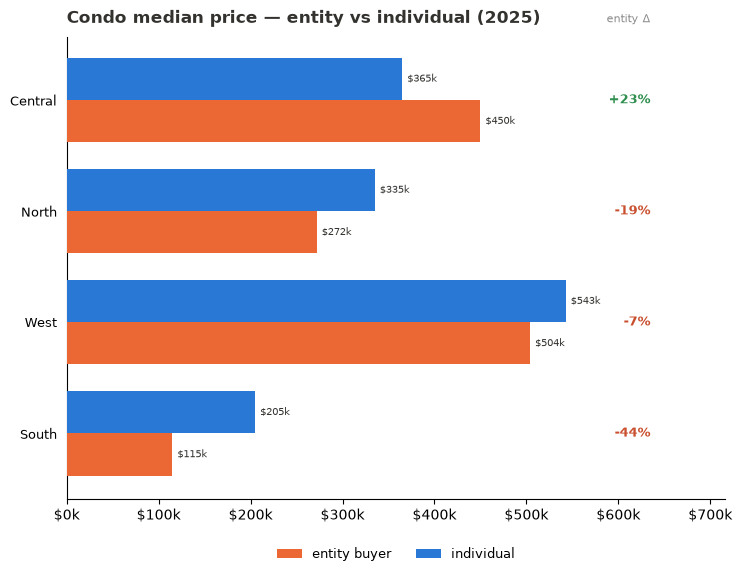

In [12]:
# Entity-buyer vs individual median PRICE, by region (2022 & 2025).
from IPython.display import display
side = sd.entity_individual_split(enriched, K.REGION_COL, years=('2022', '2025'))
display(side[['group', 'year', 'n_ent', 'n_ind', 'ent_share',
              'price_ent', 'price_ind', 'price_diff_pct']].round(0))
charts.plot_entity_metric_by_group(
    side[side['year'] == '2025'], K.CONDO.region_order, 'price',
    "Condo median price — entity vs individual (2025)", money='k')
plt.show()

,group,n_ent,n_ind,ent_share,price_ent,price_ind,price_diff_pct,reliable
0,EDGEWATER,60,417,13.000,"223,000.000","250,000.000",-11.000,True
1,LAKE VIEW,106,1041,9.000,"432,500.000","420,000.000",3.000,True
2,LINCOLN PARK,94,682,12.000,"447,500.000","592,500.000",-24.000,True
3,LOGAN SQUARE,8,297,3.000,"625,000.000","491,000.000",27.000,False
4,LOOP,58,527,10.000,"410,000.000","343,510.000",19.000,True
5,NEAR NORTH SIDE,300,1597,16.000,"455,000.000","385,000.000",18.000,True
6,NEAR SOUTH SIDE,4,375,1.000,"481,857.000","341,353.000",41.000,False
7,NEAR WEST SIDE,34,558,6.000,"340,000.000","367,814.000",-8.000,True
8,UPTOWN,20,486,4.000,"218,500.000","325,000.000",-33.000,True
9,WEST TOWN,22,711,3.000,"537,500.000","570,000.000",-6.000,True


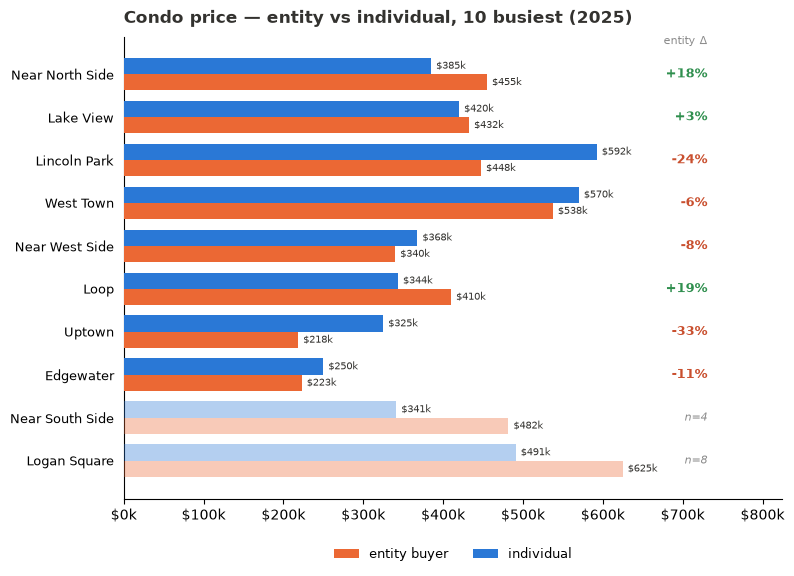

In [13]:
# 10 busiest condo neighborhoods (2025): entity vs individual price.
vol10 = sd.top_neighborhoods(
    enriched[enriched['meta_year'].astype('string') == '2025'], 10)[K.REPORT_GEO].tolist()
vol_split = sd.entity_individual_split(
    enriched[enriched[K.REPORT_GEO].isin(vol10)], K.REPORT_GEO, years=('2025',))
display(vol_split[['group', 'n_ent', 'n_ind', 'ent_share',
                   'price_ent', 'price_ind', 'price_diff_pct', 'reliable']].round(0))
charts.plot_entity_metric_by_group(
    vol_split, vol10, 'price',
    "Condo price — entity vs individual, 10 busiest (2025)", money='k')
plt.show()

,group,n_ent,n_ind,ent_share,price_ent,price_ind,price_diff_pct,reliable
0,AVONDALE,2,95,2.000,"146,900.000","360,000.000",-59.000,False
1,LAKE VIEW,106,1041,9.000,"432,500.000","420,000.000",3.000,True
2,LINCOLN PARK,94,682,12.000,"447,500.000","592,500.000",-24.000,True
3,LINCOLN SQUARE,7,178,4.000,"382,000.000","348,500.000",10.000,False
4,LOGAN SQUARE,8,297,3.000,"625,000.000","491,000.000",27.000,False
5,LOWER WEST SIDE,1,31,3.000,"479,000.000","386,000.000",24.000,False
6,NEAR NORTH SIDE,300,1597,16.000,"455,000.000","385,000.000",18.000,True
7,NEAR WEST SIDE,34,558,6.000,"340,000.000","367,814.000",-8.000,True
8,NORTH CENTER,10,203,5.000,"538,450.000","540,000.000",-0.000,True
9,WEST TOWN,22,711,3.000,"537,500.000","570,000.000",-6.000,True


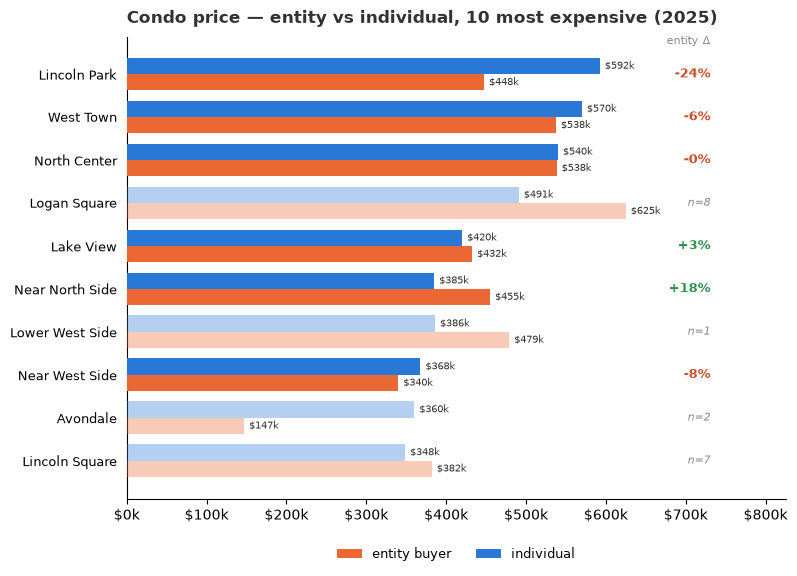

In [14]:
# 10 most expensive condo neighborhoods (2025 median, >=20 sales): entity vs individual.
exp10 = sd.neighborhoods_by_year_price(
    enriched, year='2025', min_sales=20).head(10).index.tolist()
exp_split = sd.entity_individual_split(
    enriched[enriched[K.REPORT_GEO].isin(exp10)], K.REPORT_GEO, years=('2025',))
display(exp_split[['group', 'n_ent', 'n_ind', 'ent_share',
                   'price_ent', 'price_ind', 'price_diff_pct', 'reliable']].round(0))
charts.plot_entity_metric_by_group(
    exp_split, exp10, 'price',
    "Condo price — entity vs individual, 10 most expensive (2025)", money='k')
plt.show()

---
## Q6 — Who are the condo investors, and where do they play?

**A completely different playbook from single-family — they buy *buildings*, not blocks.**
The top condo buyers are **single-building bulk acquirers**: *Duplex Tower* bought
**153 units, every one in the same Edgewater building**; *N Pine Grove* 93 units in one
Lake View building; *LaSalle Towers Property* 45 in a single Near North tower. These are
deconversion / bulk-ownership plays, not the scattered South-side rehabbers of the SF
market.

Two familiar categories return — corporate **relocation** firms (*Cartus*, *National
Residential Nominee Services*, $525–553k medians) and the *Chicago Title Land Trust*
privacy vehicle. And it's still a long tail: **4,781 entity buys across 3,589 buyers,
3,289 of whom bought exactly once.**

In [15]:
# Condo entity-buyer leaderboard (2022-25 pooled) + long-tail concentration.
from IPython.display import display
_names = sd.normalize_entity_name(enriched.loc[enriched['entity_buyer'], K.BUYER_NAME])
print(f"entity buys: {int(enriched['entity_buyer'].sum()):,}   distinct buyers: "
      f"{_names.nunique():,}   bought exactly once: {int((_names.value_counts() == 1).sum()):,}")

lb = sd.entity_buyer_leaderboard(enriched, n=15)
display(lb.style.hide(axis='index')
        .format({'median_price': '${:,.0f}', 'total_spent': '${:,.0f}'}))

entity buys: 4,781   distinct buyers: 3,589   bought exactly once: 3,289


entity,homes,median_price,total_spent,top_side,home_turf
DUPLEX TOWER,153,"$189,746","$31,234,850",North,EDGEWATER (153/153)
N PINE GROVE,93,"$210,786","$18,308,078",North,LAKE VIEW (93/93)
LASALLE TOWERS PROPERTY,45,"$219,274","$11,738,118",Central,NEAR NORTH SIDE (45/45)
VALUE DEAL PROPERTIES,43,"$215,000","$9,481,050",Central,NEAR NORTH SIDE (40/43)
LANGDON MELROSE,40,"$185,614","$7,083,448",North,LAKE VIEW (40/40)
CARTUS FINANCIAL,34,"$552,500","$21,622,698",North,LOGAN SQUARE (7/34)
CHICAGO TITLE LAND TRUST COMPANY,33,"$180,000","$15,439,510",North,CHATHAM (9/33)
EXPERTS,24,"$140,000","$3,442,800",North,LAKE VIEW (16/24)
NATIONAL RESIDENTIAL NOMINEE SERVICES,23,"$525,000","$16,899,550",North,LINCOLN PARK (6/23)
NORTH SHORE APTS,22,"$190,124","$4,071,754",North,ROGERS PARK (22/22)


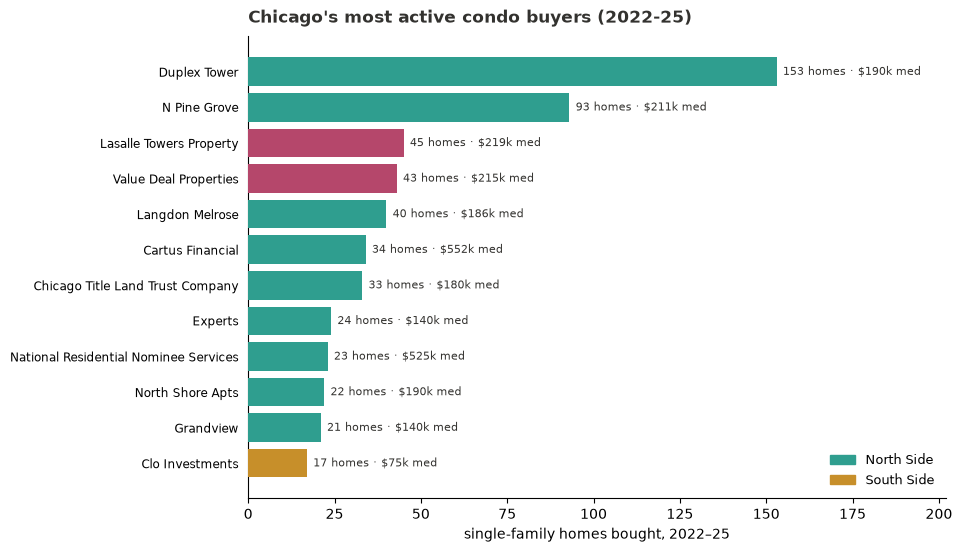

In [16]:
# Leaderboard chart — bars coloured by each buyer's home-turf region.
charts.plot_entity_buyer_leaderboard(
    lb, n=12, title="Chicago's most active condo buyers (2022-25)")
plt.show()

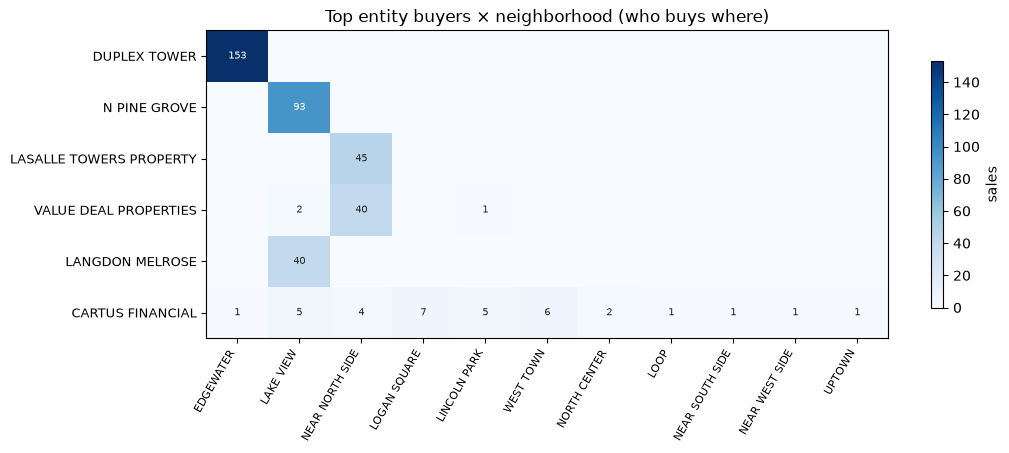

In [17]:
# Where they play — top-6 condo buyers x their most-active neighborhoods.
mat = sd.entity_neighborhood_matrix(enriched, side='buyer',
                                    top_entities_n=6, top_neighborhoods_n=12)
charts.plot_entity_neighborhood_heatmap(mat)
plt.show()

---
## Q7 — How many condos get flipped, and where?

**About 814** — condo units bought and resold within a year over 2022–25. But flipping
is a far smaller part of the condo market: only **~1.6% of condo sales** are flips,
versus ~6% for single-family homes. And it's **much less investor-driven** — just **41%
of condo flips were bought by an entity** (vs 73% for houses).

Unlike single-family flipping (a South Side trade), condo flips spread across the
**North and Central** lakefront: **Near North Side (181 flips), Lake View (110),
Edgewater (88)** lead by count, while by *share* a scatter of neighborhoods — Clearing,
Edgewater, Portage Park — top out around 3–5%. (A floor, not a census: the four-year
window only catches flips whose buy and sell both fall inside it.)

In [18]:
# Condo flips: the SAME unit bought & resold within a year (both legs arm's-length).
flip_pairs = sd.flips(enriched, max_hold_days=365)
print(f"condo flips (resold within 365 days): {len(flip_pairs):,}   "
      f"bought by an entity/LLC: {flip_pairs['entity_buyer'].mean()*100:.0f}%")
# flip SHARE of all sales, by region
sd.flip_geography(enriched, flip_pairs, by=K.REGION_COL, min_sales=0)

condo flips (resold within 365 days): 814   bought by an entity/LLC: 41%


,region,total,flips,med_return,flip_share
0,South,3745,83,0.534,2.200
1,North,25957,434,0.370,1.700
2,Central,17131,257,0.301,1.500
3,West,4396,40,0.106,0.900


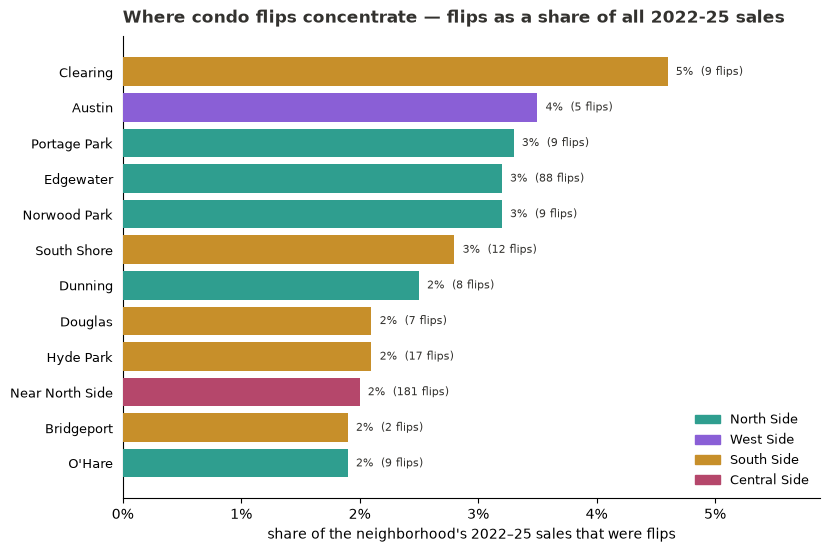

In [19]:
# Flip SHARE by neighborhood (>=100 sales) — the "1 in N sales was a flip" chart.
flip_geo = sd.flip_geography(enriched, flip_pairs, min_sales=100, n=12)
charts.plot_flip_share(
    flip_geo, n=12,
    title="Where condo flips concentrate — flips as a share of all 2022-25 sales")
plt.show()

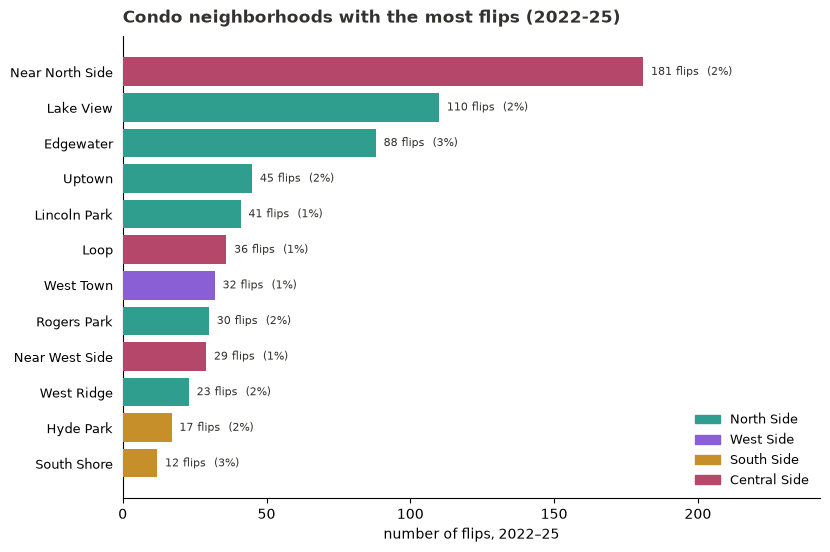

In [20]:
# Companion view — the neighborhoods with the most flips by COUNT.
flip_count = sd.flip_geography(enriched, flip_pairs, min_sales=0, n=12, sort_by='flips')
charts.plot_flip_share(
    flip_count, n=12, value='flips',
    title="Condo neighborhoods with the most flips (2022-25)")
plt.show()

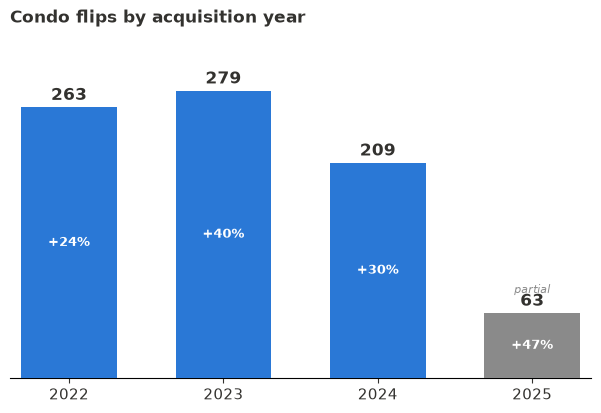

In [21]:
# Condo flips by acquisition (buy) year; 2025 greyed 'partial' (buys may not resell
# until after the data window ends). Median resale uplift labelled inside each bar.
fy = sd.flips_by_year(flip_pairs, by='buy')
charts.plot_flips_by_year(fy, partial_years=(2025,), title="Condo flips by acquisition year")
plt.show()

---
## Q8 — How fast is a condo flip, and how much does it pay?

**The median condo flip bought at ~$200k and resold for ~$289k about seven months later
— a +34% uplift.** A far cry from the +92% on single-family homes: a condo is much
harder to add value to (you can't gut-renovate a unit the way you can a distressed
house), so the margins are thinner.

The best-return neighborhoods are the North/Central lakefront — **Hyde Park +77%, Lake
View +56%, Edgewater +52%** — and the most extreme flip we found was **712 W Cornelia in
Lake View: bought for $152k, resold for $605k** (+298%) inside a year. Like houses, condo
flips overwhelmingly exit to a homeowner — **87% are resold to an individual, not another
investor.**

> **The honesty line: this is gross resale uplift, not profit.** It doesn't net out the
> renovation, assessments, carrying, or transaction costs that eat most of it — read it
> as how far the price moved, not money pocketed.

In [22]:
# The headline: median buy -> resale, and how fast (flip_pairs from Q7).
print(f"median condo flip:  buy ${flip_pairs['buy_price'].median():,.0f}  ->  resale "
      f"${flip_pairs['sell_price'].median():,.0f}   "
      f"(+{flip_pairs['gross_return'].median()*100:.0f}%, "
      f"{flip_pairs['hold_days'].median():.0f} days)")
for d in (90, 180, 270, 365):
    print(f"  flipped within {d:>3} days: {int((flip_pairs['hold_days'] <= d).sum()):,}")

median condo flip:  buy $200,000  ->  resale $289,264   (+34%, 206 days)
  flipped within  90 days: 114
  flipped within 180 days: 337
  flipped within 270 days: 576
  flipped within 365 days: 814


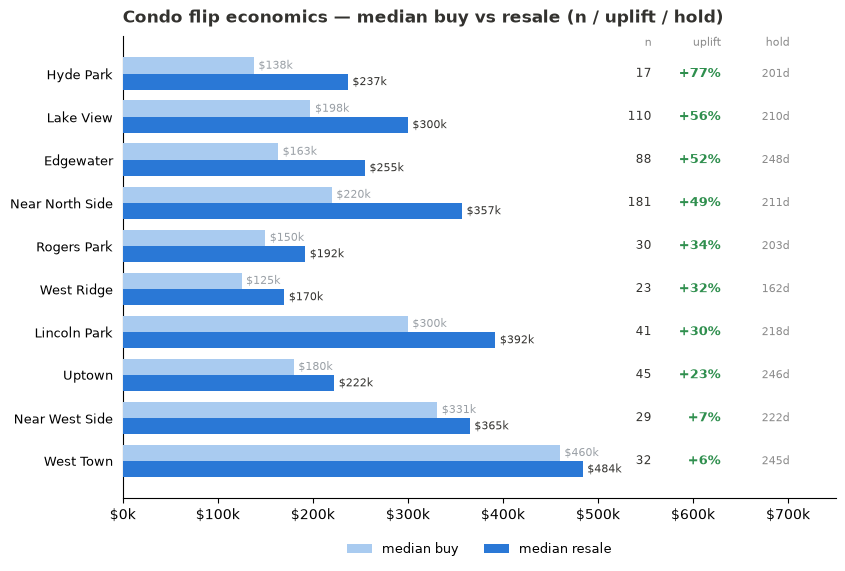

In [23]:
# Buy -> resale by neighborhood (>=15 flips), highest median uplift first.
fr = sd.flip_returns_by_neighborhood(flip_pairs, enriched, min_flips=15, n=10)
charts.plot_flip_buysell(
    fr, n=10,
    title="Condo flip economics — median buy vs resale (n / uplift / hold)")
plt.show()

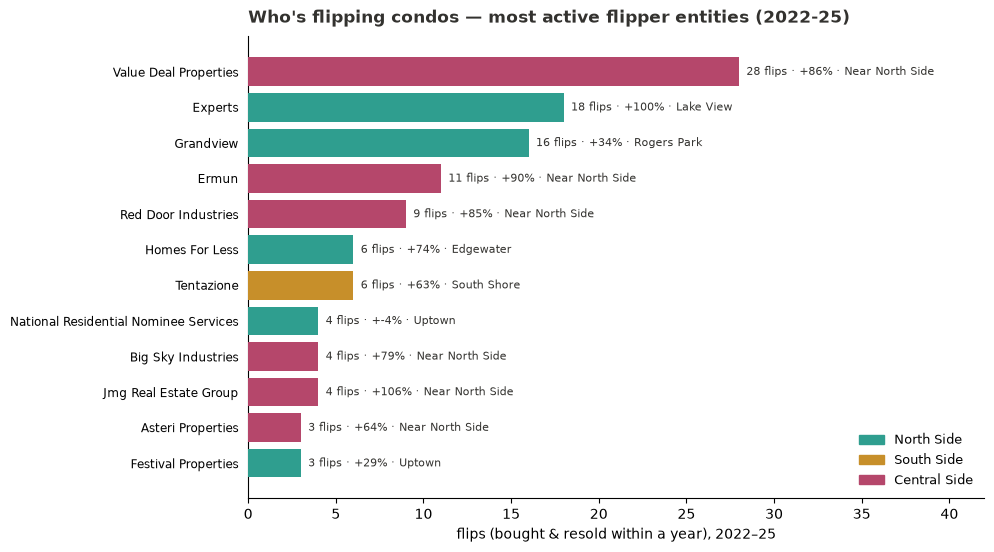

In [24]:
# Who's doing the condo flipping — most active flipper entities (the buy-leg buyer),
# coloured by home turf. Grandview shows up again; the North/Central lakefront
# specialists (Value Deal, Experts) lead on volume.
top_flip = sd.top_flippers(flip_pairs, n=12)
charts.plot_flipper_leaderboard(
    top_flip, n=12,
    title="Who's flipping condos — most active flipper entities (2022-25)")
plt.show()

In [25]:
# The jaw-droppers — biggest condo flips (held >=90 days, bought >=$25k).
# bought_by / sold_by name the flipper on entry & exit; sold_to = who they resold to,
# tagged (entity = another investor) or (retail = an individual / homeowner).
from IPython.display import display
big = (flip_pairs[(flip_pairs['hold_days'] >= 90) & (flip_pairs['buy_price'] >= 25000)]
       .nlargest(10, 'gross_return')
       .assign(**{'return_%': lambda d: (d['gross_return'] * 100).round(0).astype(int),
                  'bought_by': lambda d: sd.normalize_entity_name(d['buyer_name']),
                  'sold_by': lambda d: sd.normalize_entity_name(d['seller_name']),
                  'sold_to': lambda d: sd.normalize_entity_name(d['sold_to_name']).fillna('?')
                             + d['sold_to_entity'].map({True: ' (entity)', False: ' (retail)'}).fillna('')}))
display(big[['address', K.REPORT_GEO, 'buy_price', 'sell_price', 'hold_days',
             'return_%', 'bought_by', 'sold_by', 'sold_to']]
        .style.hide(axis='index').format({'buy_price': '${:,.0f}', 'sell_price': '${:,.0f}'}))

address,loc_chicago_community_area_name,buy_price,sell_price,hold_days,return_%,bought_by,sold_by,sold_to
712 W CORNELIA AVE 3,LAKE VIEW,"$152,000","$605,000",289,298,ANTONIO GIAMBERDUCA,ANTONIO GIAMBERDUCA,MICHAEL MOZINA (retail)
1330 N LA SALLE ST 304,NEAR NORTH SIDE,"$200,000","$787,500",153,294,MARGARET P CARLSON,MARGARET P CARLSON,ROBERT TIMOTHY VON RIBBECK KELLY (retail)
7956 S PULASKI RD 304,ASHBURN,"$45,000","$138,000",103,207,PULASKI LAND TRUST NO DATED JULY,PULASKI LAND TRUST NO,KALEB CHATMAN (retail)
601 E 32ND ST 1101,DOUGLAS,"$90,000","$265,000",139,194,CALEB E ADAMS,DEBORAH A GREEN COTTON,SANDRA MIRANDA (retail)
5471 S HYDE PARK BLVD 15B,HYDE PARK,"$91,133","$259,000",246,184,MI CASA,MI CASA,SOPHIA CLAY AND RAYMOND BUSCH AS CO TRUSTEES IN S HYDE PARK BLVD UNIT B REVOCABLE TRUST DATED OCT (entity)
1030 N STATE ST 17L,NEAR NORTH SIDE,"$240,000","$670,000",342,179,NATALIE PRINCIPE,ELPIDA PROPERTIES,AUDRE GVILDYS BAGNALL AS TRUSTEE OF AUDRE GVILDYS BAGNALL TRUST DATED NOVEMBER (entity)
3950 N LAKE SHORE DR 2220,LAKE VIEW,"$98,000","$272,000",156,178,ADVANTA IRA SERVICES LLC FBO JAMES J DOW IRA,ADVANTA IRA SERVICES LLC FBO JAMES DOW IRA,MATTHEW COKER (retail)
6300 N SHERIDAN RD 402,EDGEWATER,"$82,500","$221,000",322,168,MALIK GILLANI,MALIK GILLANI,CHRISTIAN CAMPBELL (retail)
3550 N LAKE SHORE DR 2518,LAKE VIEW,"$112,000","$297,500",174,166,TE,TE,STEVEN J ADAMS (retail)
1560 N SANDBURG TER 3003J,NEAR NORTH SIDE,"$160,000","$415,000",182,159,JMG REAL ESTATE GROUP,JMG REAL ESTATE GROUP,DOUGLAS J PRISCHAK IRREVOCABLE GRANTOR TRUST (entity)
